# Time Series Forecasting - Sales predicting

En este ejercicio intentare predecir el volumen de ventas, para poder preveer el espacio de almacenamiento necesario en los proximos meses.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = 'https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv'

df = pd.read_csv(url)

df.to_csv('../data/raw/data.csv')

In [3]:
df.shape

(366, 2)

In [4]:
df.sample(5)

,date,sales
176,2023-02-26 17:10:08.079328,505.671963
87,2022-11-29 17:10:08.079328,275.898582
322,2023-07-22 17:10:08.079328,888.905741
318,2023-07-18 17:10:08.079328,877.486354
114,2022-12-26 17:10:08.079328,345.908319


Limpio las fechas de mis datos

In [5]:
import pandas as pd

df['date'] = pd.to_datetime(df['date']).dt.normalize() # Normalize quita las horas y deja solo año, mes y dia.

df.set_index('date', inplace=True)

df.sample(5)

,sales
date,
2023-03-22,569.440400
2023-08-01,916.429348
2023-06-07,770.610592
2023-07-28,901.584529
2022-10-09,147.389502


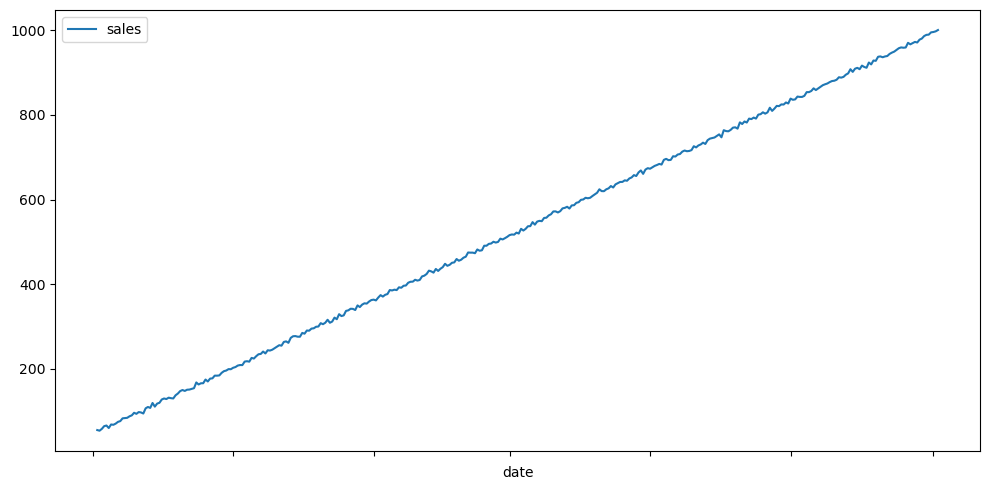

In [6]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)

axis.set_xticklabels([])

plt.tight_layout()

plt.show()

## Descomposición de la serie


In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df, period = 52) # Periodo semanal

## Análisis de la tendencia

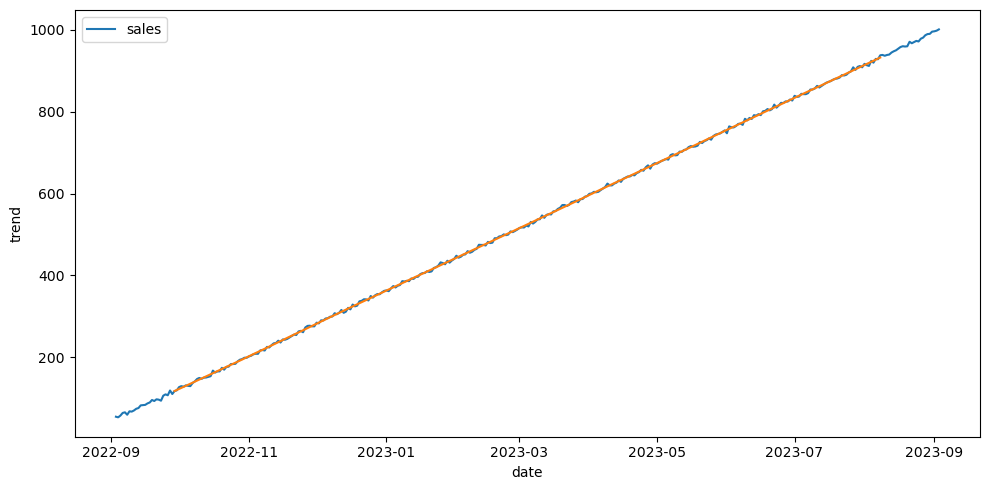

In [8]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = trend)


plt.tight_layout()

plt.show()

Se confirma una clara tendencia al alza de manera lineal a lo largo del tiempo

## Análisis de la estacionalidad


In [9]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(df)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

Dado que el p-value es superior a 0.05 descartaremos la hipotesis nula. Esto significa que la serie no es estacionaria.

## Análisis de la variabilidad


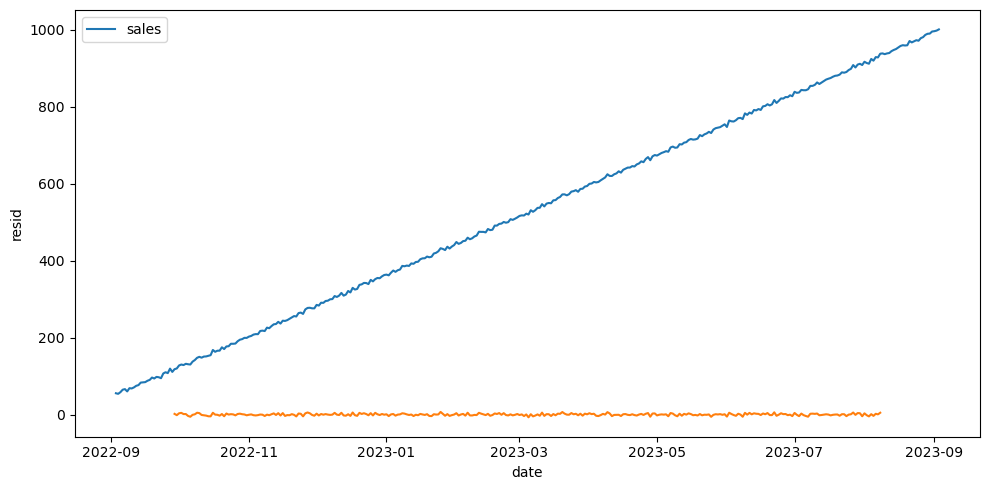

In [10]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

## Análisis de la autocorrelación¶


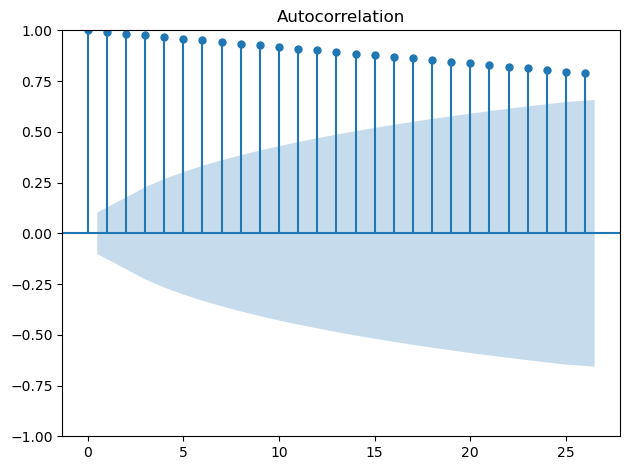

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df)

plt.tight_layout()

plt.show()

## Entrenamiento del modelo

In [ ]:
from pmdarima import auto_arima

model = auto_arima(df['sales'], seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1843.204, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1970.972, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1839.586, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2209.657, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1839.552, Time=0.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1841.532, Time=0.24 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1843.586, Time=0.10 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1839.607, Time=0.10 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1922.648, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 1.163 seconds


In [13]:
forecast = model.predict(100)
forecast

2023-09-04    1002.158148
2023-09-05    1004.831669
2023-09-06    1007.423289
2023-09-07    1010.021630
2023-09-08    1012.619419
                 ...     
2023-12-08    1249.022047
2023-12-09    1251.619878
2023-12-10    1254.217709
2023-12-11    1256.815540
2023-12-12    1259.413371
Freq: D, Length: 100, dtype: float64

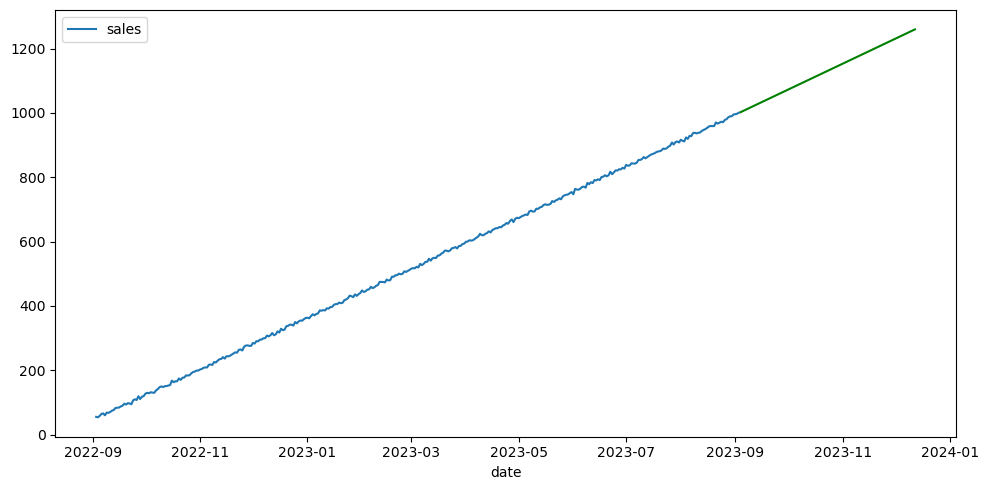

In [14]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()

plt.show()